# MLP Classifier

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from feature_distributions import apply_class_groups
from taxonomy_separability import add_relative_features
from mlp_classifier import (
    run_training,
    evaluate_val_metrics,
    plot_training_curves,
    N_BINS,
    HIDDEN_DIM,
    LEARNING_RATE,
    EPOCHS,
    BATCH_SIZE,
)

## Build features

In [2]:
df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_class_groups(df)

/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


## Batch size and learning rate

Batch size affects whether rare classes contribute to each gradient update. bus makes up only 1.9% of the 358,210 train instances (vs. 42.8% for car); at that frequency, bus is absent from 54% of batches at bs=32 and 30% at bs=64.

**Decision:** use batch_size=128, the smallest candidate keeping every class's miss probability below 10%.

Scale the learning rate accordingly:

```
lr = 1e-5 × (128 / 32) = 4e-5
```

This follows the linear scaling rule and avoids slowing training through both larger batches and a reduced learning rate.

See `MLP_Design.md` decision 1 and `scripts/batch_size_selection.py`.

## Train (cached)

3-layer MLP (65 -> 16 -> 16 -> 6) on the histogram-encoded feature vector, class-weighted cross-entropy, Adam. Config: N_BINS=16, HIDDEN_DIM=16, LEARNING_RATE=4e-5, EPOCHS=50, BATCH_SIZE=128. `run_training` loads the cached model/history if this exact config was already run - it does not retrain.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


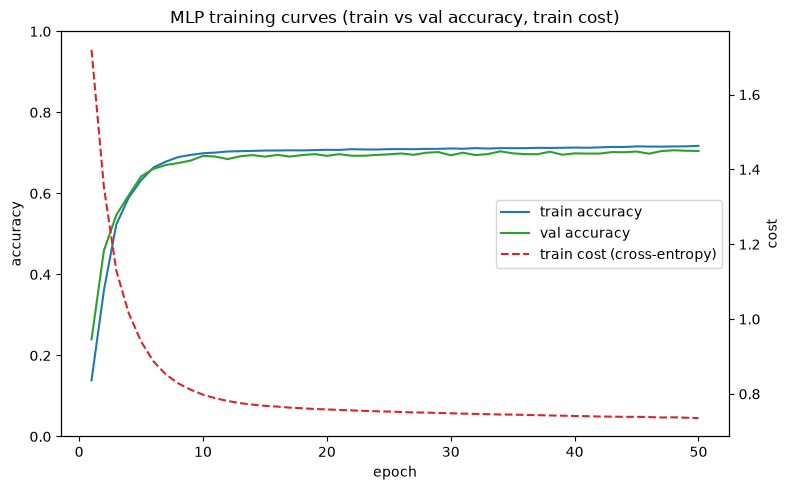

In [3]:
# uses cached model + history if EPOCHS/BATCH_SIZE/LEARNING_RATE match a prior run - no retraining
model, history, X_test, y_test = run_training(df)

Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


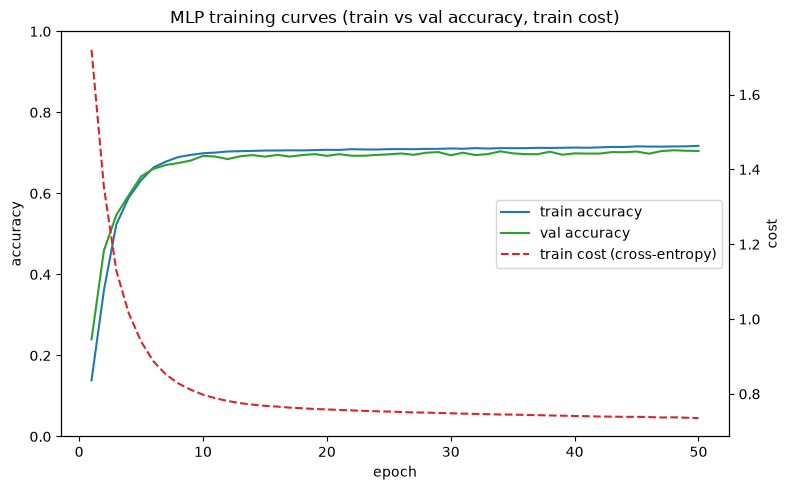

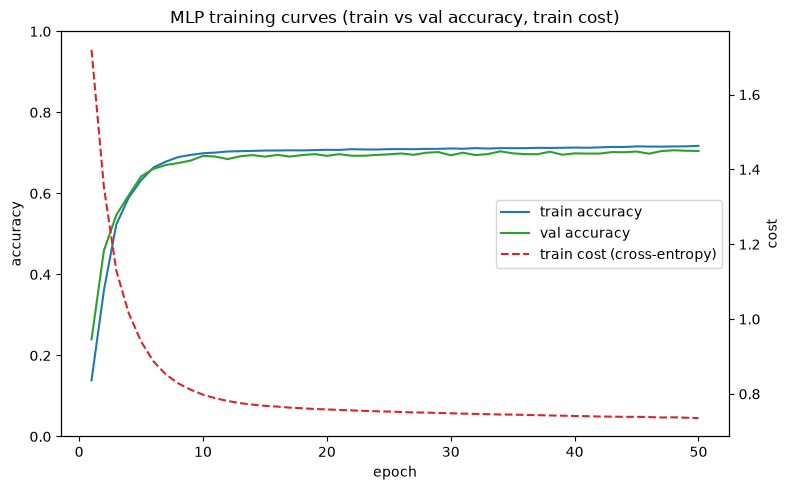

In [4]:
# train vs val accuracy and train cost, from the cached history (no retraining)
curves_fig = plot_training_curves(history)
curves_fig

## Validation metrics (cached)

Per-class precision/recall/f1, confusion matrix, and a precision/recall/f1 bar chart - computed from the cached model only, never retrains.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.935   0.727  0.818    31055
large_vehicle         0.426   0.582  0.492     4752
bus                   0.439   0.710  0.543     1495
two_wheeler           0.489   0.518  0.503     4629
pedestrian            0.552   0.857  0.672    11325
pedestrian_group      0.683   0.595  0.636    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.935471,0.727290,0.818348,31055
large_vehicle,0.425758,0.582281,0.491867,4752
bus,0.439156,0.709699,0.542572,1495
two_wheeler,0.489292,0.518254,0.503357,4629
pedestrian,0.551924,0.857395,0.671554,11325
pedestrian_group,0.683142,0.595195,0.636143,17858


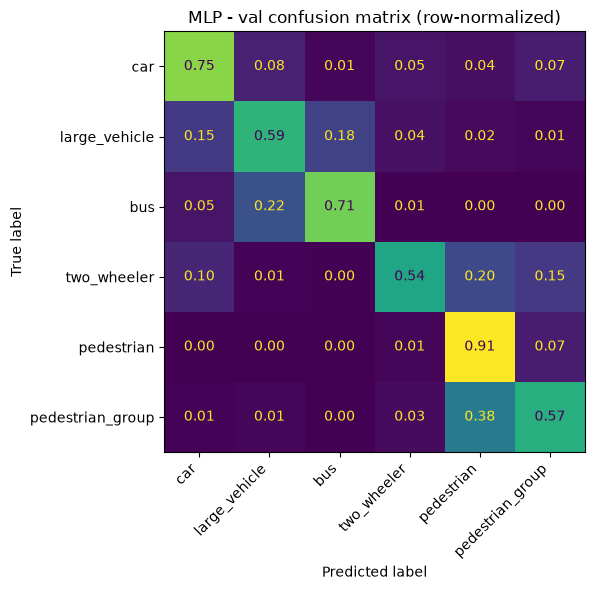

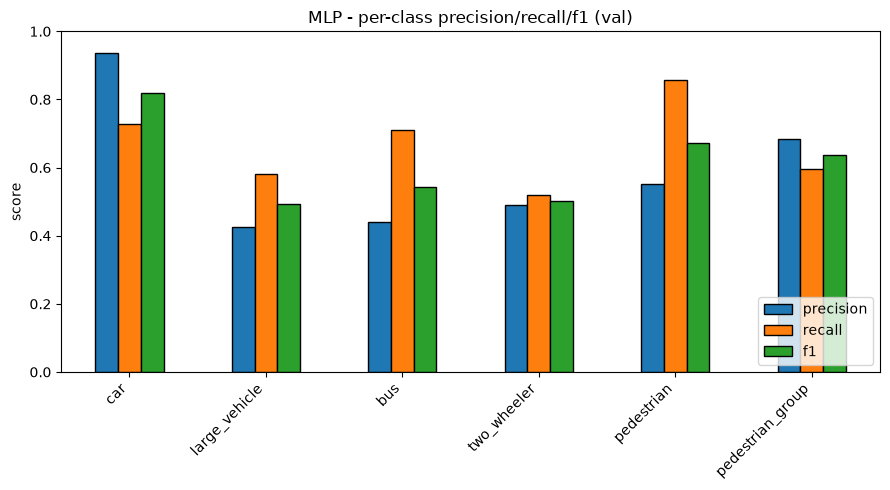

In [5]:
metrics_df, cm_fig, bar_fig = evaluate_val_metrics(df)
metrics_df

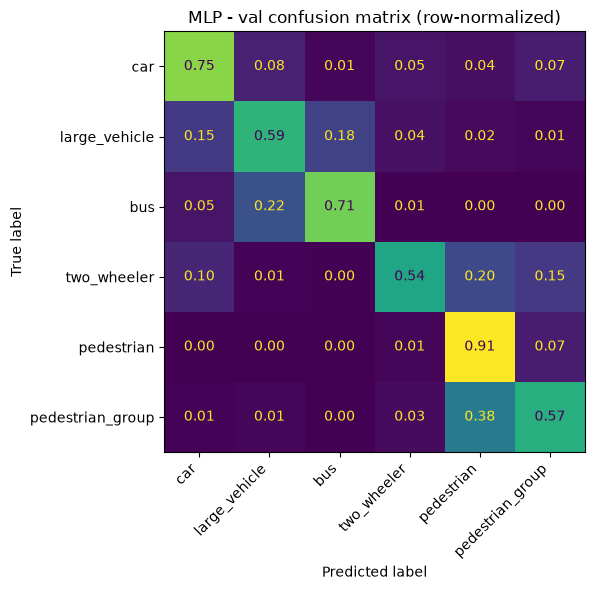

In [6]:
cm_fig

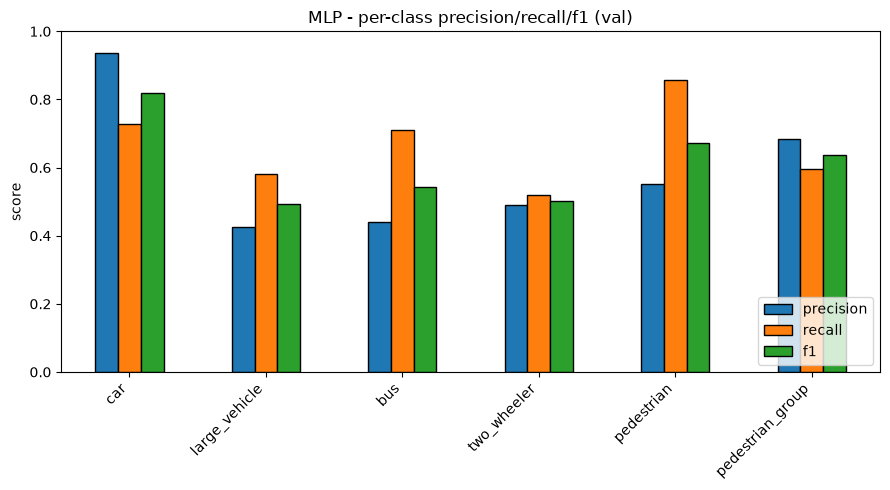

In [7]:
bar_fig

## Confusion matrix findings (epochs=50 baseline)

Row-normalized, val set:

- `car`: 73% correct - the most accurate label, and the majority class. 10% confused as `large_vehicle`.
- `large_vehicle`: confused as `car` and `bus`.
- `bus`: confused as `large_vehicle`.
- `two_wheeler`: confused as `pedestrian` and `pedestrian_group`.
- `pedestrian`: recall high.
- `pedestrian_group`: confused a lot into `pedestrian` as expected, given point sparsity (an isolated pedestrian and a sparse group can look similar with few points to work with).

**Cross-check against `MLP_Design.md` decision 2:** the confusion isn't scattered - it clusters within car/large_vehicle/bus (all "vehicle" classes) and separately within pedestrian/pedestrian_group, rather than spreading across unrelated classes. That pattern reads more like a feature-separability ceiling (the histogram features can't fully tell `bus` and `large_vehicle` apart) than pure gradient starvation. It's also in tension with the starvation story that `bus`'s recall (71%) is *higher* than `two_wheeler`'s (52%), despite `bus` being the far rarer class (1.9% vs 7.0% of train) - if rarity/starvation were the dominant driver, that ordering would likely be reversed. Oversampling may still help, but might not fully close the bus/large_vehicle gap if the ceiling is feature overlap rather than exposure.

Full writeup: `MLP_FINDINGS.md`.

## Oversampling for bus / epoch count

Increasing training from 50 to 1000 epochs did not improve bus F1; it slightly decreased, while most other classes improved. Validation accuracy also plateaued after roughly 150 to 200 epochs.

This indicates that the problem is gradient starvation rather than insufficient training: bus remains poorly represented in individual batches.

**Decision:** test weighted oversampling for bus rather than increasing the number of epochs. Oversampling should replace or reduce the existing class weighting to avoid overcompensation.

**Decision:** retain EPOCHS=50. The additional 950 epochs produced only a small macro-F1 improvement and mostly added training cost and validation noise.

See `MLP_Design.md` decision 2. 1000-epoch run: `results/mlp/epochs_1000/`.